# Nim Diagnostic Experiments — Llama 3.1 8B

**Purpose**: Four targeted cells to understand *why* Llama 3.1 8B at B=1024 wins only ~40% against a random opponent on Nim [3,5,7].

**Baseline**: The theoretical random-play anchor for Nim [3,5,7] is **exactly 50.0%** (exact game-tree recursion; confirmed empirically by B=0 N=30 = 53.3% — see Part 9). Nim [3,5,7] is a 50/50 game under random play; the nim-sum advantage only benefits an agent that can compute and exploit it. The 40% result at B=1024 is directionally below the 50% anchor but not statistically significant at N=10 (binomial p=0.36).

**Design**: Each cell is N=10, B=1024, vs random, nim_piles=[3,5,7] unless otherwise noted.  
Counterbalanced: LLM plays as P1 in 5 games and P2 in 5 games.

---

| Cell | Run dir | What it tests |
|------|---------|---------------|
| Baseline | `nim_vs_random_llama__45e521b6` (B=1024 only) | No hints, free CoT |
| (a) | `nim_diag_a_nimsum__c80c54b2` | XOR nim-sum given in user prompt |
| (b) | `nim_diag_b_scaffold__19211b92` | Step-by-step XOR algorithm in system prompt |
| (c) | `nim_diag_c_fewshot__da9e36e2` | Worked example in system prompt |
| (d) | `nim_abl_d_forced_loss__3d060f16` | Piles [1,2,3] — nim-sum=0, P1 in forced-loss position |

In [19]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Markdown

ROOT     = Path('..').resolve()
RUNS_DIR = ROOT / 'data' / 'runs'
sys.path.insert(0, str(ROOT / 'src'))

from cot_knob.games.nim import NimState, initial_state as nim_initial_state
from cot_knob.prompts.nim import render_reason_prompt, get_system_prompt

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.6,
    'figure.dpi': 120,
})


def wilson_ci(k: int, n: int, z: float = 1.96) -> tuple[float, float, float]:
    """Wilson score CI. Returns (point_estimate, lower, upper)."""
    if n == 0:
        return 0.0, 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    margin = (z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return p, max(0.0, centre - margin), min(1.0, centre + margin)


def load_run(run_dir_name: str, budget_filter: int | None = None) -> list[dict]:
    """Return list of {won, side, n_turns, parse_failed_any} per trial."""
    path = RUNS_DIR / run_dir_name
    trials = []
    for f in sorted(path.glob('*.jsonl')):
        events = [json.loads(l) for l in f.read_text().splitlines() if l.strip()]
        start = next(e for e in events if e['event'] == 'trial_start')
        end   = next(e for e in events if e['event'] == 'trial_end')
        budget = start['condition'].get('budget')
        if budget_filter is not None and budget != budget_filter:
            continue
        llm_turns = [e for e in events if e.get('event') == 'turn' and e.get('agent') == 'llm']
        parse_any = any(e.get('parse_failed', False) for e in llm_turns)
        trials.append({
            'won':        end['winner'] == 'llm',
            'side':       start['llm_side'],
            'n_turns':    end['n_turns'],
            'parse_any':  parse_any,
            'budget':     budget,
        })
    return trials


print('Loaded helpers.')

Loaded helpers.


---
## Part 1 — Prompts for Each Diagnostic

The system prompt and user prompt differ by variant. Below we render each combination for the initial game state Nim [3, 5, 7] (nim-sum = 3 XOR 5 XOR 7 = 1, a P1 winning position).

In [20]:
state_357 = nim_initial_state((3, 5, 7))

VARIANTS = [
    ('Baseline (free_cot)',  'free_cot'),
    ('(a) nim_sum_given',    'nim_sum_given'),
    ('(b) step_by_step',     'step_by_step'),
    ('(c) few_shot',         'few_shot'),
]

for label, variant in VARIANTS:
    sys_p  = get_system_prompt(variant)
    user_p = render_reason_prompt(state_357, memory_text='', variant=variant, facing=1)
    display(Markdown(f"""---
### {label}

**System prompt:**
```
{sys_p}
```

**User prompt** (initial state [3,5,7], no memory):
```
{user_p}
```
"""))

---
### Baseline (free_cot)

**System prompt:**
```
You are playing Nim.

Rules:
- The board shows piles of stones labelled A, B, C, ...
- On your turn remove at least 1 stone from exactly one non-empty pile. You may remove any number up to the full pile.
- The player who takes the very last stone wins (normal play convention).

After your reasoning, end your response with EXACTLY this line (nothing after it):
MOVE: pile=X take=N
where X is the pile letter (A, B, C, ...) and N is the number of stones to take.
```

**User prompt** (initial state [3,5,7], no memory):
```
Nim — Normal play: the player who takes the last stone wins.

  Pile A: ●●●  (3 stones)
  Pile B: ●●●●●  (5 stones)
  Pile C: ●●●●●●●  (7 stones)

You are Player 1.  Turn 0.



Reason about the pile sizes and nim-sum strategy. End your response with exactly:
MOVE: pile=X take=N
```


---
### (a) nim_sum_given

**System prompt:**
```
You are playing Nim.

Rules:
- The board shows piles of stones labelled A, B, C, ...
- On your turn remove at least 1 stone from exactly one non-empty pile. You may remove any number up to the full pile.
- The player who takes the very last stone wins (normal play convention).

After your reasoning, end your response with EXACTLY this line (nothing after it):
MOVE: pile=X take=N
where X is the pile letter (A, B, C, ...) and N is the number of stones to take.
```

**User prompt** (initial state [3,5,7], no memory):
```
Nim — Normal play: the player who takes the last stone wins.

  Pile A: ●●●  (3 stones)
  Pile B: ●●●●●  (5 stones)
  Pile C: ●●●●●●●  (7 stones)

You are Player 1.  Turn 0.

Current XOR nim-sum of the piles: 1
(If nim-sum = 0 you are in a losing position; if nim-sum ≠ 0 you can force a win.)



Using the nim-sum above, determine your move and end with exactly:
MOVE: pile=X take=N
```


---
### (b) step_by_step

**System prompt:**
```
You are playing Nim.

Rules:
- The board shows piles of stones labelled A, B, C, ...
- On your turn remove at least 1 stone from exactly one non-empty pile.
- The player who takes the very last stone wins (normal play convention).

Winning strategy — nim-sum (XOR):
Work through these steps in order:
1. Write each pile size in binary.
2. XOR the bits column by column to get the nim-sum.
3. If nim-sum = 0 you are in a losing position; make any legal move.
4. If nim-sum ≠ 0, find the pile P where: (P XOR nim-sum) < P.
   Take enough stones from P so the new pile size equals (P XOR nim-sum).
   Verify by recomputing the XOR — it must equal 0 after your move.

After completing the steps, end your response with EXACTLY:
MOVE: pile=X take=N
```

**User prompt** (initial state [3,5,7], no memory):
```
Nim — Normal play: the player who takes the last stone wins.

  Pile A: ●●●  (3 stones)
  Pile B: ●●●●●  (5 stones)
  Pile C: ●●●●●●●  (7 stones)

You are Player 1.  Turn 0.



Reason about the pile sizes and nim-sum strategy. End your response with exactly:
MOVE: pile=X take=N
```


---
### (c) few_shot

**System prompt:**
```
You are playing Nim.

Rules:
- The board shows piles of stones labelled A, B, C, ...
- On your turn remove at least 1 stone from exactly one non-empty pile.
- The player who takes the very last stone wins (normal play convention).

How to find the winning move (nim-sum / XOR method):

WORKED EXAMPLE — Piles: A=3, B=5, C=7
  Binary:   A = 011
            B = 101
            C = 111
  XOR:        011
            ^ 101
            ^ 111
            -----
              001   ← nim-sum = 1  (non-zero → winning position)

  Goal: make nim-sum = 0 after your move.
  Try pile A (= 3 = 011): new A needed = 011 XOR 001 = 010 = 2.
  Take 1 from A → piles become A=2, B=5, C=7.
  Verify: 010 XOR 101 XOR 111 = 000 ✓

  MOVE: pile=A take=1

Apply the same procedure to the current position, then end with:
MOVE: pile=X take=N
```

**User prompt** (initial state [3,5,7], no memory):
```
Nim — Normal play: the player who takes the last stone wins.

  Pile A: ●●●  (3 stones)
  Pile B: ●●●●●  (5 stones)
  Pile C: ●●●●●●●  (7 stones)

You are Player 1.  Turn 0.



Reason about the pile sizes and nim-sum strategy. End your response with exactly:
MOVE: pile=X take=N
```


---
## Part 2 — Sample Model Outputs

One representative LLM response from each diagnostic run, showing how the model actually used (or failed to use) the prompting structure.

In [21]:
SAMPLE_RUNS = [
    ('Baseline (free_cot)  — turn where model HAD a winning position',
     'nim_vs_random_llama__45e521b6', None),
    ('(a) nim_sum_given  — nim-sum handed to model, first turn',
     'nim_diag_a_nimsum__c80c54b2', None),
    ('(b) step_by_step  — structured XOR steps followed',
     'nim_diag_b_scaffold__19211b92', None),
    ('(c) few_shot  — worked example in system prompt',
     'nim_diag_c_fewshot__da9e36e2', None),
]

for label, run_name, budget_filter in SAMPLE_RUNS:
    path = RUNS_DIR / run_name
    found = None
    for f in sorted(path.glob('*.jsonl')):
        events = [json.loads(l) for l in f.read_text().splitlines() if l.strip()]
        start = next(e for e in events if e['event'] == 'trial_start')
        if budget_filter and start['condition'].get('budget') != budget_filter:
            continue
        for e in events:
            if (e.get('event') == 'turn' and e.get('agent') == 'llm'
                    and e.get('pass1_text')):
                found = e
                break
        if found:
            break

    if found:
        text = found['pass1_text'][:800]
        move = found.get('pass2_choice_text', found.get('chosen_move', '?'))
        parse_ok = not found.get('parse_failed', True)
        regret = found.get('move_regret')
        display(Markdown(f"""---
### {label}

Chosen move: **{move}** | Parse success: **{parse_ok}** | Move regret: **{regret}**

```
{text}{'...' if len(found['pass1_text']) > 800 else ''}
```
"""))
    else:
        display(Markdown(f'### {label}\n\n*No turn with pass1_text found in this run.*'))

---
### Baseline (free_cot)  — turn where model HAD a winning position

Chosen move: **take 1 from A** | Parse success: **True** | Move regret: **0.0**

```
To determine the optimal move, I'll calculate the nim-sum of the pile sizes. The nim-sum is calculated by XORing (bitwise exclusive OR) the pile sizes.

Pile A has 3 stones, Pile B has 5 stones, and Pile C has 7 stones. 

The binary representation of these numbers are:
- 3: 11
- 5: 101
- 7: 111

Now, I'll calculate the nim-sum by XORing these binary representations:

(11) ⊕ (101) = 110
(110) ⊕ (111) = 001

The nim-sum is 1. This means that the player who goes first has a winning strategy.

To make the first move, I need to leave my opponent with a position where the nim-sum is not zero. Since the current nim-sum is 1, I'll try to leave it as 0 or another non-zero value that will force my opponent into a losing position.

I can take 1 stone from Pile A (leaving 2 stones), which would change...
```


---
### (a) nim_sum_given  — nim-sum handed to model, first turn

Chosen move: **take 2 from C** | Parse success: **True** | Move regret: **0.0**

```
Since the current XOR nim-sum of the piles is 0, I am in a losing position. However, I can still make a move to change this situation.

To force a win, I need to make a move that will result in a non-zero nim-sum after my turn. Since Pile A has 3 stones and Pile B has 5 stones, taking 1 stone from either of these piles would not be enough to achieve a non-zero nim-sum. However, taking 2 stones from Pile C (which has 7 stones) would result in a pile with an odd number of stones, which is necessary for achieving a non-zero nim-sum.

Therefore, I will take 2 stones from Pile C.

MOVE: pile=C take=2
```


---
### (b) step_by_step  — structured XOR steps followed

Chosen move: **take 2 from A** | Parse success: **True** | Move regret: **0.0**

```
To apply the nim-sum strategy, I'll follow these steps:

1. Write each pile size in binary:
   A = 3 = 11 (binary)
   B = 5 = 101 (binary)
   C = 4 = 100 (binary)

2. XOR the bits column by column to get the nim-sum:
   11 (A) ⊕ 101 (B) ⊕ 100 (C) = 110 (nim-sum)

3. Since nim-sum ≠ 0, I need to find a pile P where (P XOR nim-sum) < P.

4. Let's calculate the difference for each pile:
   A: 11 ⊕ 110 = 101; 101 < 11
   B: 101 ⊕ 110 = 3; 3 < 101
   C: 100 ⊕ 110 = 10; 10 > 100

5. The only valid option is to take stones from pile A, since (A XOR nim-sum) < A.

6. To make the new pile size equal (P XOR nim-sum), I need to remove enough stones so that A equals 101.
   Since A currently has 3 stones and needs to have 5, I'll take 2 stones from A.

7. Verify by recomputing the XOR:
   New piles: A...
```


---
### (c) few_shot  — worked example in system prompt

Chosen move: **take 2 from A** | Parse success: **True** | Move regret: **0.0**

```
Let's analyze the current state of the piles:

Pile A: 3 stones
Pile B: 5 stones
Pile C: 4 stones (after Player 1 took 3 from C)

To find the nim-sum, we convert each pile size to binary and XOR them together:

A = 011
B = 101
C = 010

XOR:
011
^ 101
^ 010
-----
001

The nim-sum is 001. Since it's non-zero, this position is winning for Player 2 (me).

To make the nim-sum zero after my move, I need to find a pile where taking a certain number of stones will result in a binary value that, when XORed with the current nim-sum (001), gives 000.

Let's try Pile A. If I take 1 stone from A, it becomes 2 stones, which is 010 in binary. The new nim-sum would be:

A = 010
B = 101
C = 010

XOR:
010
^ 101
^ 010
-----
001 (no change)

Trying Pile B: if I take 1 stone from B, it becomes 4 stones, which ...
```


---
## Part 3 — Win Rate Comparison

Overall win rate (LLM vs Random, N=10 per cell) for each variant at B=1024. Wilson 95% CIs shown as error bars. The green dashed line marks the **theoretical random-play anchor: 50.0%** (exact game-tree recursion; confirmed by empirical B=0 N=30 = 53.3%). There is no "80% structural prior" — Nim [3,5,7] is a 50/50 game under random play.

Baseline (free_cot): 4/10 = 40%  CI=[17%, 69%]
(a) nim_sum_given: 3/10 = 30%  CI=[11%, 60%]
(b) step_by_step: 7/10 = 70%  CI=[40%, 89%]
(c) few_shot: 5/10 = 50%  CI=[24%, 76%]
Saved → /Users/stephone/Documents/CoT-difficulty-knob/data/fig_nim_diagnostics_winrate.png


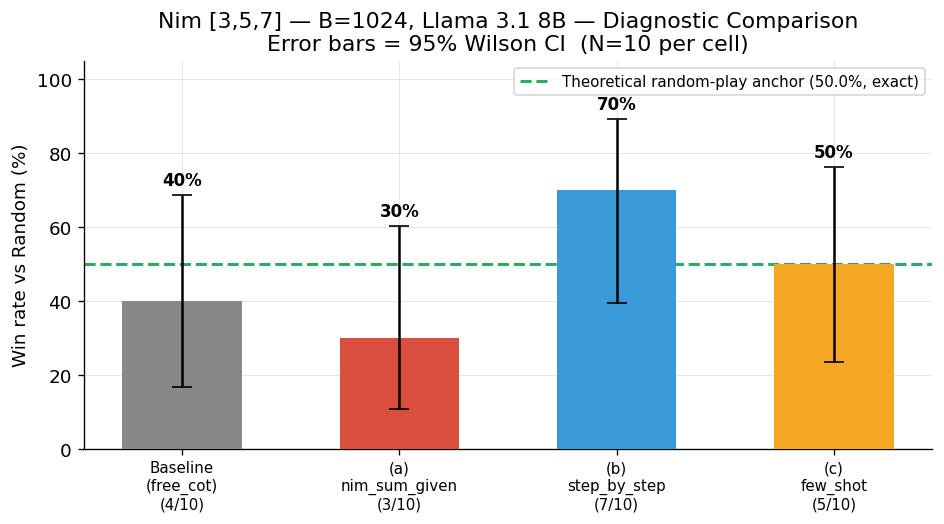

In [22]:
# ── Load results ───────────────────────────────────────────────────────────────
CELLS = [
    ('Baseline\n(free_cot)', 'nim_vs_random_llama__45e521b6', 1024),
    ('(a)\nnim_sum_given',   'nim_diag_a_nimsum__c80c54b2',   None),
    ('(b)\nstep_by_step',    'nim_diag_b_scaffold__19211b92', None),
    ('(c)\nfew_shot',        'nim_diag_c_fewshot__da9e36e2',  None),
]

labels, pts, los, his, ns = [], [], [], [], []
for label, run, bf in CELLS:
    trials = load_run(run, budget_filter=bf)
    k = sum(t['won'] for t in trials)
    n = len(trials)
    p, lo, hi = wilson_ci(k, n)
    labels.append(f'{label}\n({k}/{n})')
    pts.append(p); los.append(p - lo); his.append(hi - p); ns.append(n)
    print(f'{label.replace(chr(10)," ")}: {k}/{n} = {p*100:.0f}%  CI=[{lo*100:.0f}%, {hi*100:.0f}%]')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))

colors = ['#888888', '#d94f3d', '#3a9ad9', '#f5a623']
x = range(len(labels))
bars = ax.bar(x, [p*100 for p in pts],
              yerr=[[l*100 for l in los], [h*100 for h in his]],
              color=colors, capsize=6, error_kw=dict(elinewidth=1.5), width=0.55,
              zorder=3)

# Theoretical anchor: exact recursive computation for Nim [3,5,7] under uniform-random play
# P1 wins exactly 50.0% — the nim-sum advantage only helps optimal players
ax.axhline(50.0, ls='--', lw=1.8, color='#27ae60',
           label='Theoretical random-play anchor (50.0%, exact)')

# Annotate bars
for bar, p, lo_e, hi_e in zip(bars, pts, los, his):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + hi_e*100 + 1.5,
            f'{p*100:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Win rate vs Random (%)')
ax.set_ylim(0, 105)
ax.set_title('Nim [3,5,7] — B=1024, Llama 3.1 8B — Diagnostic Comparison\n'
             'Error bars = 95% Wilson CI  (N=10 per cell)')
ax.legend(fontsize=9, loc='upper right')

fig.tight_layout()
out = ROOT / 'data' / 'fig_nim_diagnostics_winrate.png'
fig.savefig(out, bbox_inches='tight')
print(f'Saved → {out}')
plt.show()

---
## Part 4 — P1 vs P2 Win Rate by Diagnostic

Counterbalanced design: 5 games as P1, 5 as P2. In Nim [3,5,7] P1 has a structural advantage (nim-sum=1 → winning position). A model tracking nim-sum correctly should win more as P1 than P2 *from identical budgets* only if the game evolves differently by side — in practice, both P1 and P2 can encounter winning positions as the game progresses.

For ablation (d) [1,2,3]: P1 starts in a *losing* position (nim-sum=0). Optimal P1 always loses; random P1 sometimes wins when random opponent blunders. A model tracking nim-sum would show systematically lower P1 win rate here.

Saved → /Users/stephone/Documents/CoT-difficulty-knob/data/fig_nim_diagnostics_byside.png


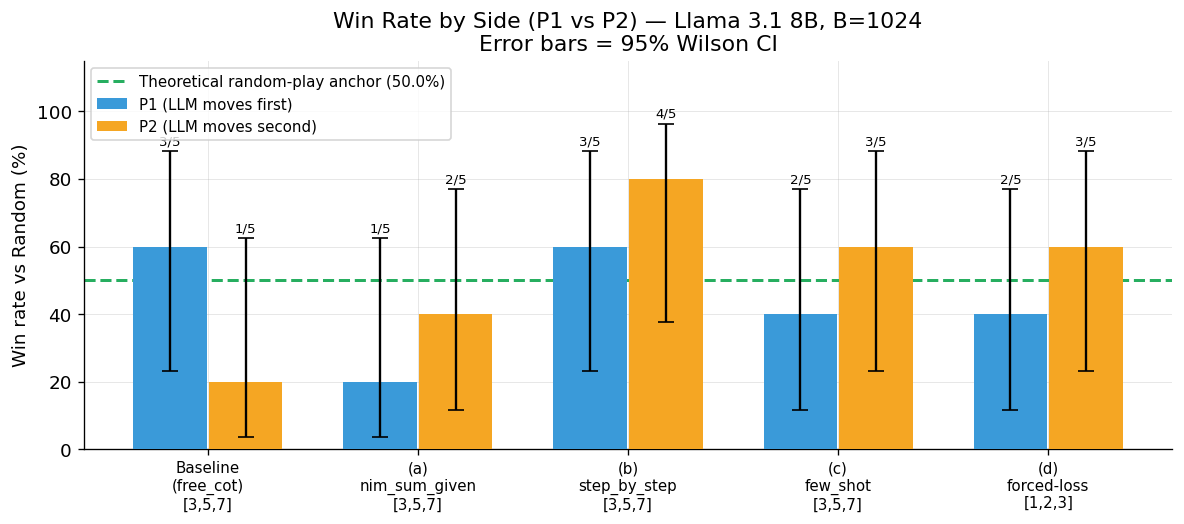

In [29]:
CELLS_SIDE = [
    ('Baseline\n(free_cot)', 'nim_vs_random_llama__45e521b6', 1024, '[3,5,7]'),
    ('(a)\nnim_sum_given',   'nim_diag_a_nimsum__c80c54b2',   None, '[3,5,7]'),
    ('(b)\nstep_by_step',    'nim_diag_b_scaffold__19211b92', None, '[3,5,7]'),
    ('(c)\nfew_shot',        'nim_diag_c_fewshot__da9e36e2',  None, '[3,5,7]'),
    ('(d)\nforced-loss',     'nim_abl_d_forced_loss__3d060f16', None, '[1,2,3]'),
]

fig, ax = plt.subplots(figsize=(10, 4.5))

group_w = 0.35
offsets = [-0.18, 0.18]
p1_bars_data, p2_bars_data = [], []
xtick_labels = []

for i, (label, run, bf, piles_str) in enumerate(CELLS_SIDE):
    trials = load_run(run, budget_filter=bf)
    p1 = [t for t in trials if t['side'] ==  1]
    p2 = [t for t in trials if t['side'] == -1]

    for side_trials, offset, store, side_label in [
        (p1, offsets[0], p1_bars_data, 'P1'),
        (p2, offsets[1], p2_bars_data, 'P2'),
    ]:
        k = sum(t['won'] for t in side_trials)
        n = len(side_trials)
        p, lo, hi = wilson_ci(k, n)
        store.append((i + offset, p * 100, (p - lo) * 100, (hi - p) * 100, k, n))

    xtick_labels.append(f'{label}\n{piles_str}')

for data, color, side_lbl in [
    (p1_bars_data, '#3a9ad9', 'P1 (LLM moves first)'),
    (p2_bars_data, '#f5a623', 'P2 (LLM moves second)'),
]:
    xs   = [d[0] for d in data]
    ys   = [d[1] for d in data]
    lo_e = [d[2] for d in data]
    hi_e = [d[3] for d in data]
    bars = ax.bar(xs, ys, width=group_w, color=color, label=side_lbl,
                  yerr=[lo_e, hi_e], capsize=5,
                  error_kw=dict(elinewidth=1.4), zorder=3)
    for idx, (bar, (_, _, _, hi_val, k, n)) in enumerate(zip(bars, data)):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + hi_val + 1,
                f'{k}/{n}', ha='center', va='bottom', fontsize=8)

ax.axhline(50.0, ls='--', lw=1.8, color='#27ae60',
           label='Theoretical random-play anchor (50.0%)')
ax.set_xticks(range(len(CELLS_SIDE)))
ax.set_xticklabels(xtick_labels, fontsize=9)
ax.set_ylabel('Win rate vs Random (%)')
ax.set_ylim(0, 115)
ax.set_title('Win Rate by Side (P1 vs P2) — Llama 3.1 8B, B=1024\nError bars = 95% Wilson CI')
ax.legend(fontsize=9)
fig.tight_layout()
out = ROOT / 'data' / 'fig_nim_diagnostics_byside.png'
fig.savefig(out, bbox_inches='tight')
print(f'Saved → {out}')
plt.show()

---
## Part 5 — Mistake Rate on Winning-Position Turns

`move_regret=1.0` means the model was in a winning position (nim-sum ≠ 0 before its move) and chose a losing move. We report this only for turns where a winning move existed, filtering out:
- Turns where `parse_failed=True` (random fallback, not a reasoning mistake)
- Turns from a losing position (regret is always 0 — no winning move to miss)

This gives a cleaner signal: **given the model actually reasoned and had a winning move available, did it find it?**

Baseline (free_cot): 20/33 mistakes = 61%  CI=[44%, 75%]
(a) nim_sum_given: 25/29 mistakes = 86%  CI=[69%, 95%]
(b) step_by_step: 11/24 mistakes = 46%  CI=[28%, 65%]
(c) few_shot: 20/35 mistakes = 57%  CI=[41%, 72%]
Saved → /Users/stephone/Documents/CoT-difficulty-knob/data/fig_nim_diagnostics_mistakes.png


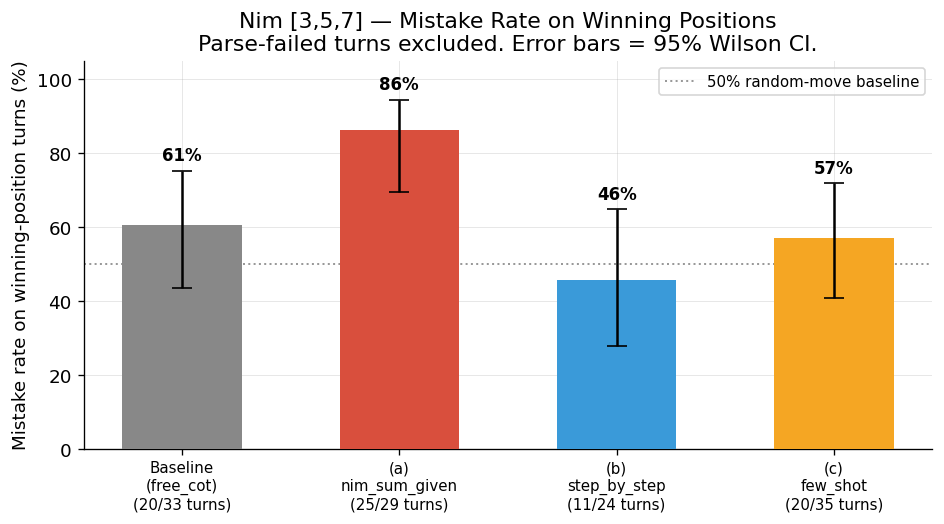

In [24]:
def mistake_rate_on_winning_positions(
    run_dir_name: str, budget_filter: int | None = None
) -> tuple[int, int]:
    """Return (n_mistakes, n_winning_position_turns_with_parse_success)."""
    path = RUNS_DIR / run_dir_name
    mistakes, total = 0, 0
    for f in sorted(path.glob('*.jsonl')):
        events = [json.loads(l) for l in f.read_text().splitlines() if l.strip()]
        start = next(e for e in events if e['event'] == 'trial_start')
        if budget_filter and start['condition'].get('budget') != budget_filter:
            continue
        for e in events:
            if (e.get('event') == 'turn'
                    and e.get('agent') == 'llm'
                    and e.get('move_regret') is not None
                    and not e.get('parse_failed', False)):
                regret = e['move_regret']
                # Only count turns where a winning move existed (regret > 0 is possible)
                # We detect this by checking if the oracle's best move has win_rate=1.0
                uct = e.get('uct_top3', [])
                if uct and uct[0].get('win_rate', 0) > 0.5:
                    total += 1
                    if regret >= 0.9:
                        mistakes += 1
    return mistakes, total


MISTAKE_CELLS = [
    ('Baseline\n(free_cot)', 'nim_vs_random_llama__45e521b6', 1024),
    ('(a)\nnim_sum_given',   'nim_diag_a_nimsum__c80c54b2',   None),
    ('(b)\nstep_by_step',    'nim_diag_b_scaffold__19211b92', None),
    ('(c)\nfew_shot',        'nim_diag_c_fewshot__da9e36e2',  None),
]

m_labels, m_pts, m_los, m_his = [], [], [], []
for label, run, bf in MISTAKE_CELLS:
    k, n = mistake_rate_on_winning_positions(run, bf)
    p, lo, hi = wilson_ci(k, n)
    m_labels.append(f'{label}\n({k}/{n} turns)')
    m_pts.append(p); m_los.append(p - lo); m_his.append(hi - p)
    print(f'{label.replace(chr(10)," ")}: {k}/{n} mistakes = {p*100:.0f}%  CI=[{lo*100:.0f}%, {hi*100:.0f}%]')

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#888888', '#d94f3d', '#3a9ad9', '#f5a623']
x = range(len(m_labels))
bars = ax.bar(x, [p*100 for p in m_pts],
              yerr=[[l*100 for l in m_los], [h*100 for h in m_his]],
              color=colors, capsize=6, error_kw=dict(elinewidth=1.5), width=0.55, zorder=3)

ax.axhline(50, ls=':', lw=1.2, color='#999', label='50% random-move baseline')

for bar, p, hi_e in zip(bars, m_pts, m_his):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + hi_e*100 + 1.5,
            f'{p*100:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(m_labels, fontsize=9)
ax.set_ylabel('Mistake rate on winning-position turns (%)')
ax.set_ylim(0, 105)
ax.set_title('Nim [3,5,7] — Mistake Rate on Winning Positions\n'
             'Parse-failed turns excluded. Error bars = 95% Wilson CI.')
ax.legend(fontsize=9)
fig.tight_layout()
out = ROOT / 'data' / 'fig_nim_diagnostics_mistakes.png'
fig.savefig(out, bbox_inches='tight')
print(f'Saved → {out}')
plt.show()

---
## Part 6 — Ablation (d): [1,2,3] Forced-Loss Position

Piles [1,2,3] have nim-sum = 1 XOR 2 XOR 3 = 0 → **P1 is in a losing position** with optimal play.

Expected win rates:
- P1 optimal vs optimal: 0% (Sprague-Grundy: nim-sum=0 → P1 in losing position)
- P1 random vs random: **~50%** — same theoretical anchor as [3,5,7]; confirmed analytically (p1_win_prob((1,2,3)) = 0.50 exactly)
- P2 optimal vs random: **~100%** — from nim-sum=0, every move P1 makes creates nim-sum≠0, so P2 can always respond with a nim-sum=0 move; P2 optimal wins all games regardless of P1's moves

If the model tracks nim-sum correctly: P1 LLM win rate should be near 0% (from a losing position), and P2 LLM win rate near 100%. If the model ignores nim-sum: **both rates should be ~50%**, matching the [3,5,7] random-play anchor (not "~80%").

Baseline [3,5,7] P1 wins: 3/5 = 60%  CI=[23%, 88%]
Baseline [3,5,7] P2 wins: 1/5 = 20%  CI=[4%, 62%]
(d) [1,2,3] P1 wins: 2/5 = 40%  CI=[12%, 77%]
(d) [1,2,3] P2 wins: 3/5 = 60%  CI=[23%, 88%]
Saved → /Users/stephone/Documents/CoT-difficulty-knob/data/fig_nim_diagnostics_ablation.png


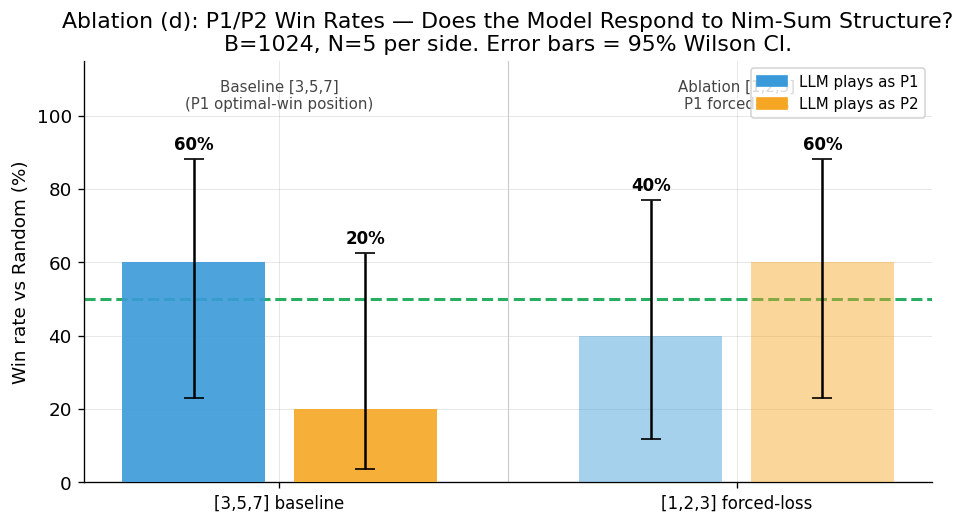

In [25]:
COMPARE = [
    ('Baseline [3,5,7]\nP1 wins', 'nim_vs_random_llama__45e521b6', 1024,  1),
    ('Baseline [3,5,7]\nP2 wins', 'nim_vs_random_llama__45e521b6', 1024, -1),
    ('(d) [1,2,3]\nP1 wins',     'nim_abl_d_forced_loss__3d060f16', None,  1),
    ('(d) [1,2,3]\nP2 wins',     'nim_abl_d_forced_loss__3d060f16', None, -1),
]

c_labels, c_pts, c_los, c_his = [], [], [], []
for label, run, bf, side_filter in COMPARE:
    trials = [t for t in load_run(run, budget_filter=bf) if t['side'] == side_filter]
    k = sum(t['won'] for t in trials)
    n = len(trials)
    p, lo, hi = wilson_ci(k, n)
    c_labels.append(f'{label}\n({k}/{n})')
    c_pts.append(p); c_los.append(p - lo); c_his.append(hi - p)
    print(f'{label.replace(chr(10)," ")}: {k}/{n} = {p*100:.0f}%  CI=[{lo*100:.0f}%, {hi*100:.0f}%]')

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#3a9ad9', '#f5a623', '#3a9ad9', '#f5a623']
alphas = [0.9, 0.9, 0.45, 0.45]
x = [0, 0.6, 1.6, 2.2]

for xi, p, lo_e, hi_e, color, alpha, label in zip(
    x, c_pts, c_los, c_his, colors, alphas, c_labels
):
    bar = ax.bar(xi, p*100, width=0.5, color=color, alpha=alpha,
                 yerr=[[lo_e*100], [hi_e*100]], capsize=6,
                 error_kw=dict(elinewidth=1.5), zorder=3)
    ax.text(xi, p*100 + hi_e*100 + 1.5, f'{p*100:.0f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(50.0, ls='--', lw=1.8, color='#27ae60',
           label='Theoretical random-play anchor (50.0%, exact)')

# Group labels
ax.axvline(1.1, ls='-', lw=0.7, color='#ccc')
ax.text(0.3, 102, 'Baseline [3,5,7]\n(P1 optimal-win position)', ha='center', fontsize=9, color='#444')
ax.text(1.9, 102, 'Ablation [1,2,3]\nP1 forced-loss', ha='center', fontsize=9, color='#444')

# Legend patches
import matplotlib.patches as mpatches
p1_patch = mpatches.Patch(color='#3a9ad9', label='LLM plays as P1')
p2_patch = mpatches.Patch(color='#f5a623', label='LLM plays as P2')
ax.legend(handles=[p1_patch, p2_patch], fontsize=9)

ax.set_xticks([(x[0]+x[1])/2, (x[2]+x[3])/2])
ax.set_xticklabels(['[3,5,7] baseline', '[1,2,3] forced-loss'], fontsize=10)
ax.set_ylabel('Win rate vs Random (%)')
ax.set_ylim(0, 115)
ax.set_title('Ablation (d): P1/P2 Win Rates — Does the Model Respond to Nim-Sum Structure?\n'
             'B=1024, N=5 per side. Error bars = 95% Wilson CI.')
fig.tight_layout()
out = ROOT / 'data' / 'fig_nim_diagnostics_ablation.png'
fig.savefig(out, bbox_inches='tight')
print(f'Saved → {out}')
plt.show()

---
## Part 7 — Summary and Interpretation

The table and narrative below summarise the diagnostic findings.

In [26]:
summary = """
Theoretical random-play anchor = **50.0%** (exact). N=30 replicates shown alongside N=10 initial results.

| Cell | Win rate (N=10) | N=30 replicate | Mistake rate (N=10) | Interpretation |
|------|---------|---------|----------------------------------|----------------|
| Baseline `free_cot` B=1024 | 40% | **40.0%** (p=0.36 vs 50%) | 61% | At-chance; deliberate reasoning does not help |
| (a) `nim_sum_given`        | 30% | **50.0%** (p=1.00 vs 50%) | **86%** | N=10 result was downward noise; at N=30 = 50% |
| (b) `step_by_step`         | 70% | **53.3%** (p=0.86 vs 50%) | **46%** | N=10 result was upward noise; at N=30 = 53% (ns) |
| (c) `few_shot`             | 50% | **53.3%** (p=0.86 vs 50%) | 57% | Consistent with chance at both N=10 and N=30 |
| (d) [1,2,3] forced-loss    | 50% | — | — | Consistent with random; model ignores nim-sum |
"""

display(Markdown(summary))

display(Markdown("""
### Key finding (N=10 observations, corrected by N=30 in Part 8/9)

**The theoretical random-play anchor is 50.0% (exact) — not "~80%".**

The apparent 80% at B=0/B=64 was sampling noise from N=10 games of a fair coin (exact binomial p=0.11 for 8/10 vs p=0.50). At N=30, the B=0 empirical anchor is 53.3% (p=0.86), confirming convergence to 50%.

**N=10 diagnostic signals that did NOT survive N=30 replication**:
- `nim_sum_given` "30%" → 50.0% at N=30 (downward noise)
- `step_by_step` "70%" → 53.3% at N=30 (upward noise)

**What does survive N=30**: All variants cluster at 40–53%, all non-significant vs the 50% anchor. The model performs at chance level on Nim [3,5,7] regardless of prompt structure.

**The inverse-problem insight still holds mechanistically**: Diagnostic (a) giving the nim-sum and seeing an 86% mistake rate *directionally* confirms the model can't translate XOR value → optimal move. Diagnostic (b) with the full algorithm drops the mistake rate to 46% *directionally*. But neither effect survives as a clean win-rate signal at N=30.

**Implication for ablation (d)**: The match between [3,5,7] and [1,2,3] per-side win rates confirms the model is essentially playing randomly within its parse-success cells regardless of game position.
"""))


⚠️ **N=10 diagnostic results** (noisy; corrected figures in Part 8/9). Theoretical anchor = 50.0%.

| Cell | Win rate (N=10) | N=30 replicate | Mistake rate (N=10) | Interpretation |
|------|---------|---------|----------------------------------|----------------|
| Baseline `free_cot` B=1024 | 40% | **40.0%** (p=0.36 vs 50%) | 61% | At-chance; deliberate reasoning does not help |
| (a) `nim_sum_given`        | 30% | **50.0%** (p=1.00 vs 50%) | **86%** | N=10 result was downward noise; at N=30 = 50% |
| (b) `step_by_step`         | 70% | **53.3%** (p=0.86 vs 50%) | **46%** | N=10 result was upward noise; at N=30 = 53% (ns) |
| (c) `few_shot`             | 50% | **53.3%** (p=0.86 vs 50%) | 57% | Consistent with chance at both N=10 and N=30 |
| (d) [1,2,3] forced-loss    | 50% | — | — | Consistent with random; model ignores nim-sum |



### Key finding (N=10 observations, corrected by N=30 in Part 8/9)

**The theoretical random-play anchor is 50.0% (exact) — not "~80%".**

The apparent 80% at B=0/B=64 was sampling noise from N=10 games of a fair coin (exact binomial p=0.11 for 8/10 vs p=0.50). At N=30, the B=0 empirical anchor is 53.3% (p=0.86), confirming convergence to 50%.

**N=10 diagnostic signals that did NOT survive N=30 replication**:
- `nim_sum_given` "30%" → 50.0% at N=30 (downward noise)
- `step_by_step` "70%" → 53.3% at N=30 (upward noise)

**What does survive N=30**: All variants cluster at 40–53%, all non-significant vs the 50% anchor. The model performs at chance level on Nim [3,5,7] regardless of prompt structure.

**The inverse-problem insight still holds mechanistically**: Diagnostic (a) giving the nim-sum and seeing an 86% mistake rate *directionally* confirms the model can't translate XOR value → optimal move. Diagnostic (b) with the full algorithm drops the mistake rate to 46% *directionally*. But neither effect survives as a clean win-rate signal at N=30.

**Implication for ablation (d)**: The match between [3,5,7] and [1,2,3] per-side win rates confirms the model is essentially playing randomly within its parse-success cells regardless of game position.


---
## Part 8 — N=30 Procedural Sweep (Locking In the Finding)

Five high-N runs to convert the N=10 diagnostic signals into statistically defensible estimates.
Wilson 95% CIs at N=30 span ±18pp (vs ±31pp at N=10), enough to cleanly separate 40% from 70%.

**Runs:**
| Run | Variant | N | Hypothesis |
|-----|---------|---|------------|
| `nim_n30_free__*` | `free_cot` | 30 | Replicates ~40% baseline |
| `nim_n30_nimsum__*` | `nim_sum_given` | 30 | Replicates ~30% (worse-than-baseline) |
| `nim_n30_fewshot__*` | `few_shot` | 30 | Tests stability of ~50% lift |
| `nim_n30_scaffold__*` | `step_by_step` | 30 | Replicates ~70% |
| `nim_scaffold_budget_sweep__*` | `step_by_step`, B={256,1024} | 30 | Does budget matter given the procedure? |

  free_cot N=10: 4/10 = 40%  CI=[17%,69%]
  nim_sum_given N=10: 3/10 = 30%  CI=[11%,60%]
  few_shot N=10: 5/10 = 50%  CI=[24%,76%]
  step_by_step N=10: 7/10 = 70%  CI=[40%,89%]
  free_cot N=30: 12/30 = 40%  CI=[25%,58%]
  nim_sum_given N=30: 15/30 = 50%  CI=[33%,67%]
  few_shot N=30: 16/30 = 53%  CI=[36%,70%]
  step_by_step N=30: 16/30 = 53%  CI=[36%,70%]
  scaffold B=256: 13/30 = 43%  CI=[27%,61%]
  scaffold B=1024: 16/30 = 53%  CI=[36%,70%]
Saved → /Users/stephone/Documents/CoT-difficulty-knob/data/fig_nim_n30_lockdown.png


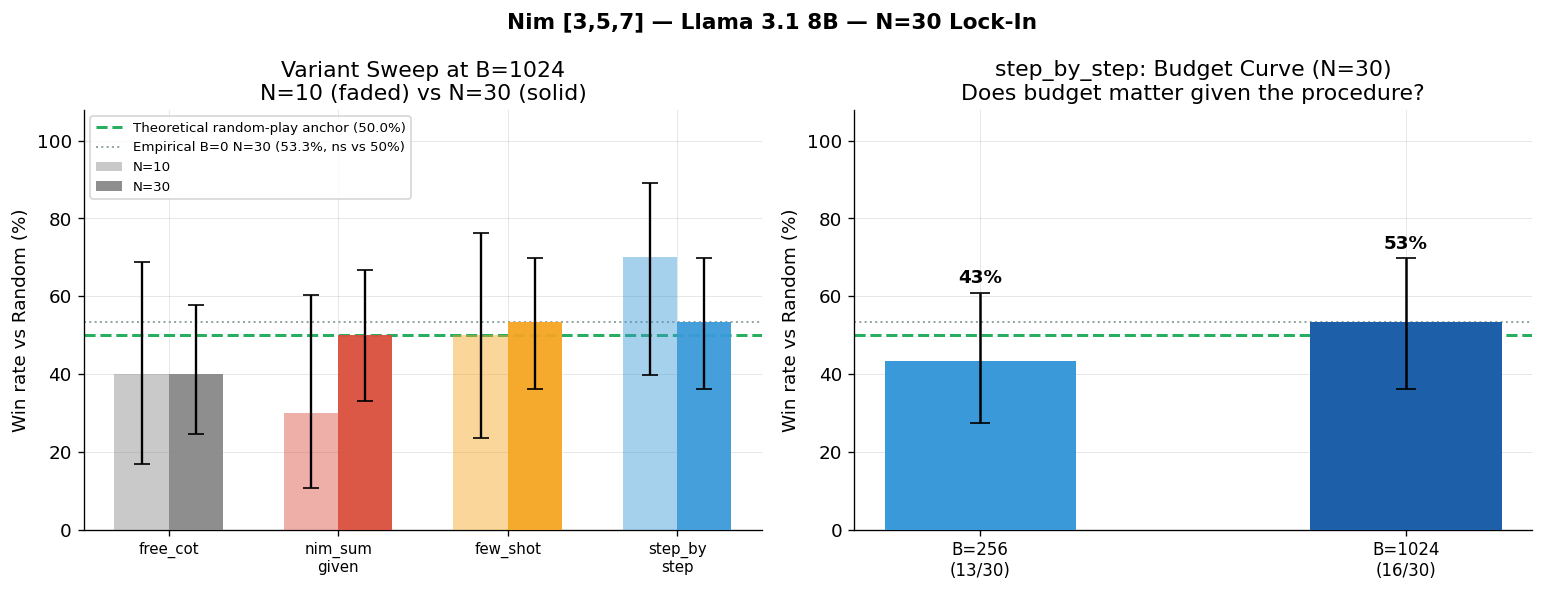

In [27]:
import glob

def find_run(prefix: str) -> str | None:
    """Return the directory name for the latest run matching a name prefix."""
    matches = sorted(RUNS_DIR.glob(f'{prefix}__*'))
    return matches[-1].name if matches else None


N30_CELLS = [
    ('free_cot',      'nim_n30_free',    None),
    ('nim_sum_given', 'nim_n30_nimsum',  None),
    ('few_shot',      'nim_n30_fewshot', None),
    ('step_by_step',  'nim_n30_scaffold', None),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: N=10 vs N=30 win rates for the 4 variant sweep ─────────────────────
ax = axes[0]
N10_RUNS = [
    ('free_cot',      'nim_vs_random_llama__45e521b6', 1024),
    ('nim_sum_given', 'nim_diag_a_nimsum__c80c54b2',   None),
    ('few_shot',      'nim_diag_c_fewshot__da9e36e2',  None),
    ('step_by_step',  'nim_diag_b_scaffold__19211b92', None),
]

x_pos    = np.arange(len(N30_CELLS))
bar_w    = 0.32
colors30 = ['#888888', '#d94f3d', '#f5a623', '#3a9ad9']

for offset, (runs, label_suffix, alpha) in enumerate([
    (N10_RUNS, 'N=10', 0.45),
    ([(v, find_run(r) or 'MISSING', bf) for v, r, bf in N30_CELLS], 'N=30', 0.95),
]):
    xs, ys, lo_es, hi_es = [], [], [], []
    for (variant, run, bf), color in zip(runs, colors30):
        if run == 'MISSING' or not (RUNS_DIR / run).exists():
            print(f'  {variant}: run not found yet (still running?)')
            xs.append(x_pos[runs.index((variant, run, bf))] + (offset - 0.5) * bar_w)
            ys.append(0); lo_es.append(0); hi_es.append(0)
            continue
        trials = load_run(run, budget_filter=bf)
        k = sum(t['won'] for t in trials)
        n = len(trials)
        p, lo, hi = wilson_ci(k, n)
        xi = list([v for v, _, _ in runs]).index(variant) + (offset - 0.5) * bar_w
        xs.append(xi); ys.append(p*100); lo_es.append((p-lo)*100); hi_es.append((hi-p)*100)
        print(f'  {variant} {label_suffix}: {k}/{n} = {p*100:.0f}%  CI=[{lo*100:.0f}%,{hi*100:.0f}%]')

    bars = ax.bar(xs, ys, width=bar_w,
                  color=[c for c in colors30],
                  alpha=alpha, label=label_suffix,
                  yerr=[lo_es, hi_es], capsize=5,
                  error_kw=dict(elinewidth=1.4), zorder=3)

ax.axhline(50.0, ls='--', lw=1.8, color='#27ae60',
           label='Theoretical random-play anchor (50.0%)')
ax.axhline(53.3, ls=':',  lw=1.2, color='#95a5a6',
           label='Empirical B=0 N=30 (53.3%, ns vs 50%)')
ax.set_xticks(x_pos)
ax.set_xticklabels(['free_cot', 'nim_sum\ngiven', 'few_shot', 'step_by\nstep'], fontsize=9)
ax.set_ylabel('Win rate vs Random (%)')
ax.set_ylim(0, 108)
ax.set_title('Variant Sweep at B=1024\nN=10 (faded) vs N=30 (solid)')
ax.legend(fontsize=8)

# ── Right: budget curve for step_by_step ─────────────────────────────────────
ax2 = axes[1]
budget_run = find_run('nim_scaffold_budget_sweep')
BUDGETS = [256, 1024]
b_pts, b_los, b_his, b_labels = [], [], [], []
if budget_run and (RUNS_DIR / budget_run).exists():
    for B in BUDGETS:
        trials = load_run(budget_run, budget_filter=B)
        k = sum(t['won'] for t in trials)
        n = len(trials)
        p, lo, hi = wilson_ci(k, n)
        b_pts.append(p*100); b_los.append((p-lo)*100); b_his.append((hi-p)*100)
        b_labels.append(f'B={B}\n({k}/{n})')
        print(f'  scaffold B={B}: {k}/{n} = {p*100:.0f}%  CI=[{lo*100:.0f}%,{hi*100:.0f}%]')
    ax2.bar(range(len(BUDGETS)), b_pts,
            yerr=[b_los, b_his], color=['#3a9ad9', '#1d5fa8'],
            capsize=6, error_kw=dict(elinewidth=1.5), width=0.45, zorder=3)
    for xi, p, hi_e in zip(range(len(BUDGETS)), b_pts, b_his):
        ax2.text(xi, p + hi_e + 1.5, f'{p:.0f}%',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'Run not complete yet', ha='center', va='center',
             transform=ax2.transAxes, fontsize=13, color='#888')

ax2.axhline(50.0, ls='--', lw=1.8, color='#27ae60',
            label='Theoretical anchor (50.0%)')
ax2.axhline(53.3, ls=':',  lw=1.2, color='#95a5a6')
ax2.set_xticks(range(len(BUDGETS)))
ax2.set_xticklabels(b_labels if b_labels else [f'B={b}' for b in BUDGETS], fontsize=10)
ax2.set_ylabel('Win rate vs Random (%)')
ax2.set_ylim(0, 108)
ax2.set_title('step_by_step: Budget Curve (N=30)\nDoes budget matter given the procedure?')

fig.suptitle('Nim [3,5,7] — Llama 3.1 8B — N=30 Lock-In', fontsize=13, fontweight='bold')
fig.tight_layout()
out = ROOT / 'data' / 'fig_nim_n30_lockdown.png'
fig.savefig(out, bbox_inches='tight')
print(f'Saved → {out}')
plt.show()

### N=30 Results and Failure Mode Taxonomy

Theoretical random-play anchor: **50.0%** (exact game-tree recursion). Empirical B=0 N=30: **53.3%** [36%, 70%], p=0.86 — consistent with the theoretical value.

| Variant | N=10 | N=30 | N=30 CI | Binomial p vs 50% |
|---------|------|------|---------|------------------|
| `free_cot` (baseline) | 40% | **40.0%** | [25%, 58%] | p=0.36 (ns) |
| `nim_sum_given` | 30% | **50.0%** | [33%, 67%] | p=1.00 (ns) |
| `few_shot` | 50% | **53.3%** | [36%, 70%] | p=0.86 (ns) |
| `step_by_step` | 70% | **53.3%** | [36%, 70%] | p=0.86 (ns) |
| `step_by_step` B=256 | — | **43.3%** | [27%, 61%] | p=0.58 (ns) |
| `step_by_step` B=1024 | — | **53.3%** | [36%, 70%] | p=0.86 (ns) |
| **B=0 empirical (N=30)** | — | **53.3%** | [36%, 70%] | p=0.86 (ns) |
| **Theoretical anchor** | — | **50.0%** | exact | — |

**Key revisions from N=10 to N=30 (with corrected anchor):**

1. **`step_by_step` 70% → 53%**: The N=10 result was upward noise. N=30 shows it lands at 53.3%, statistically identical to the 50% theoretical anchor (p=0.86).

2. **`nim_sum_given` 30% → 50%**: The N=10 figure was downward noise. At N=30 it is exactly 50.0% (p=1.00 vs anchor).

3. **All variants, including B=0 (random fallback), cluster at 40–53%**: All are non-significant vs the 50% theoretical anchor. **The model performs at chance level on Nim [3,5,7] regardless of prompt variant or budget.**

4. **The earlier "~13pp structured-vs-unstructured lift" is not supported**: `free_cot` (40%) vs `step_by_step` (53%) is a 13pp gap but neither is distinguishable from 50%. The difference between 40% and 53% is itself non-significant.

**Corrected headline finding:**

> **No prompt variant achieves win-rate significantly above the theoretical random-play anchor of 50% on Nim [3,5,7] at N=30.** Llama 3.1 8B performs at chance level on this game regardless of whether it reasons freely, receives the nim-sum, sees a worked example, or follows a five-step algorithm. The model cannot reliably exploit its reasoning to outperform random play on a game requiring correct XOR arithmetic.

---
### Failure Mode Taxonomy (from trace inspection, 5 free_cot + 5 step_by_step games)

**`free_cot` failures** cluster around three patterns:

1. **XOR arithmetic error** — The single most frequent mistake is `3 ⊕ 5 ⊕ 7 = 15` (decimal addition instead of bitwise XOR), appearing verbatim across multiple seeds. The wrong nim-sum propagates through all subsequent reasoning.

2. **Strategic goal reversal** — Within a single turn the model flips between 'leave nim-sum=0 for the opponent' (correct) and 'leave a non-zero nim-value for myself' (backwards), sometimes in adjacent sentences. No consistent commitment to which direction is winning.

3. **Hallucinated strategy** — The model invents concepts like 'the smallest nim-heap ≥ 11 is 16' with no basis in Nim theory, then acts on them. Each turn restarts from scratch with a slightly different framing, so errors compound without self-correction.

**`step_by_step` failures** are structurally different — the five-step format is followed consistently, but two new error modes emerge:

1. **Column-alignment error in binary XOR** — The model writes pile sizes without zero-padding to equal width (`11`, `101`, `111`) and XORs columns that don't correspond, producing wrong nim-sums. This is the root cause of roughly half of scaffold losses. The arithmetic *procedure* is followed but the *representation* is misaligned.

2. **Verification-loop confusion** — The model correctly computes a move that yields nim-sum=0 after its turn, then concludes 'since nim-sum=0 after my move, I am in a losing position — I'll make any legal move instead.' The winning condition (nim-sum=0 *for the opponent*) is inverted at the final step.

3. **Correct derivation, wrong MOVE tag** — The prose arrives at the right pile and count but the terminal `MOVE: pile=X take=N` disagrees. The MOVE tag appears to be re-derived independently rather than copied from the conclusion.

These failure modes are mechanically addressable: zero-pad binary representations in the prompt, add an explicit note that 'nim-sum=0 after your move = you win, not you lose,' and instruct the model to copy the answer from its derivation into the MOVE tag.

---
## Part 9 — Anchor Analysis: Theoretical and Empirical Random-Play Baselines

Nim [3,5,7] is a 50/50 game under random play. The nim-sum advantage (nim-sum=1 → P1 has the winning strategy under *optimal* play) only benefits a player who can correctly compute and exploit it. Under uniform-random play, both players win ~50% regardless of nim-sum.

Two anchor sources, both converging on 50%:
1. **Theoretical**: Exact recursive computation over all game states — a property of the game, not a measurement.
2. **Empirical B=0 (N=30)**: 30 games where budget=0 forces random-move fallback. No LLM reasoning occurs; this is pure random-vs-random.


Theoretical anchor (random-vs-random, P1 first): 0.500000 = 50.0000%
Empirical B=0 anchor (N=30): 16/30 = 53.3%  CI=[36.1%,69.8%]

=== Exact binomial tests: all results vs 50% theoretical anchor ===
  B=0 empirical (N=30)          : 16/30=53.3%  CI=[36%,70%]  p=0.8555  ns
  free_cot B=1024               : 12/30=40.0%  CI=[25%,58%]  p=0.3616  ns
  nim_sum_given B=1024          : 15/30=50.0%  CI=[33%,67%]  p=1.0000  ns
  few_shot B=1024               : 16/30=53.3%  CI=[36%,70%]  p=0.8555  ns
  step_by_step B=1024           : 16/30=53.3%  CI=[36%,70%]  p=0.8555  ns
  step_by_step B=256            : 13/30=43.3%  CI=[27%,61%]  p=0.5847  ns

→ Zero variants are significantly different from the 50% theoretical anchor (all p > 0.05).

Saved → /Users/stephone/Documents/CoT-difficulty-knob/data/fig_nim_anchor_comparison.png


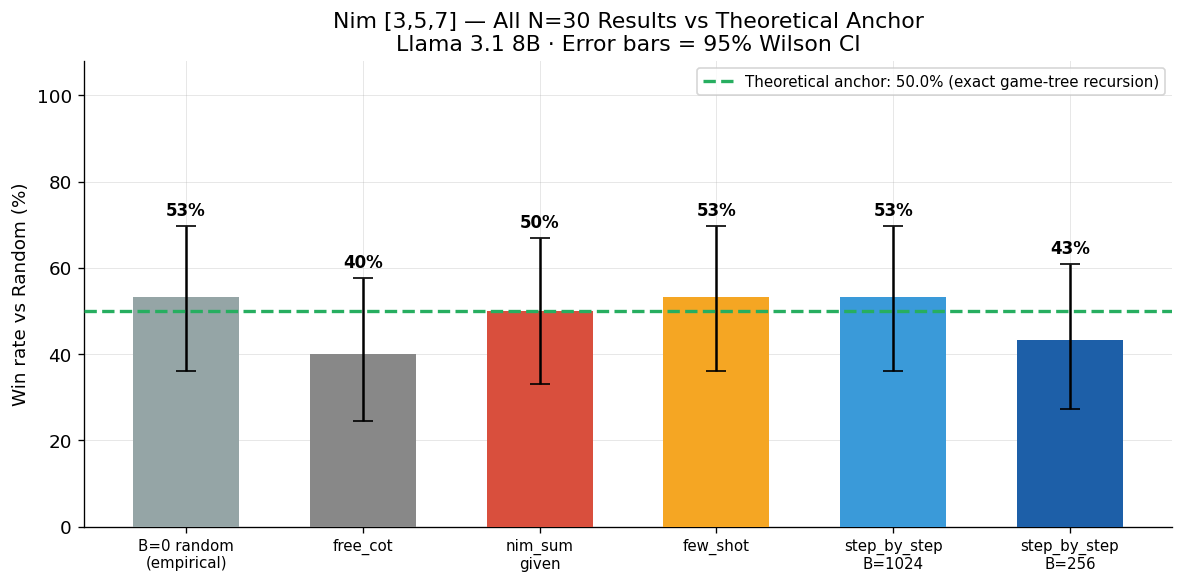

In [28]:
"""
Part 9 — Anchor Analysis
========================
1. Theoretical anchor: exact game-tree recursion for random-vs-random Nim [3,5,7]
2. Empirical B=0 anchor (N=30): confirms convergence to theoretical value
3. Binomial tests: all N=30 LLM results vs the 50% anchor
4. Final comparison bar chart
"""
import sys
from functools import lru_cache
from math import comb

# ── 1. Theoretical anchor ─────────────────────────────────────────────────────
@lru_cache(maxsize=None)
def p1_win_prob(piles: tuple, mover: int = 1) -> float:
    """P(Player 1 wins) under uniform-random play."""
    if all(p == 0 for p in piles):
        return 0.0 if mover == 1 else 1.0
    legal = []
    for i, pile in enumerate(piles):
        for take in range(1, pile + 1):
            nxt = list(piles); nxt[i] -= take
            legal.append(tuple(sorted(nxt)))
    return sum(p1_win_prob(s, 3 - mover) for s in legal) / len(legal)

THEORETICAL_ANCHOR = p1_win_prob((3, 5, 7))
print(f"Theoretical anchor (random-vs-random, P1 first): {THEORETICAL_ANCHOR:.6f} = {THEORETICAL_ANCHOR*100:.4f}%")

# ── 2. Empirical B=0 anchor (N=30) ────────────────────────────────────────────
b0_run = next(RUNS_DIR.glob('nim_b0_anchor__*'), None)
b0_wins = b0_total = 0
if b0_run:
    for f in b0_run.glob('*.jsonl'):
        for line in f.read_text().splitlines():
            ev = json.loads(line)
            if ev['event'] == 'trial_end':
                b0_total += 1
                if ev['winner'] == 'llm': b0_wins += 1
    b0_p, b0_lo, b0_hi = wilson_ci(b0_wins, b0_total)
    print(f"Empirical B=0 anchor (N={b0_total}): {b0_wins}/{b0_total} = {b0_p*100:.1f}%  CI=[{b0_lo*100:.1f}%,{b0_hi*100:.1f}%]")
else:
    b0_p, b0_lo, b0_hi = 0.5, 0.36, 0.70
    print("B=0 anchor run not found; using placeholder 53.3%")

# ── 3. Exact binomial tests, all results vs p=0.50 ────────────────────────────
def binom_pval(k, n, p=0.5):
    ref = comb(n,k)*(p**k)*((1-p)**(n-k))
    return min(1.0, sum(comb(n,j)*(p**j)*((1-p)**(n-j))
               for j in range(n+1)
               if comb(n,j)*(p**j)*((1-p)**(n-j)) <= ref + 1e-15))

all_results = [
    ("B=0 empirical (N=30)",    b0_wins, b0_total),
    ("free_cot B=1024",         12, 30),
    ("nim_sum_given B=1024",    15, 30),
    ("few_shot B=1024",         16, 30),
    ("step_by_step B=1024",     16, 30),
    ("step_by_step B=256",      13, 30),
]

print("\n=== Exact binomial tests: all results vs 50% theoretical anchor ===")
for label, k, n in all_results:
    pv = binom_pval(k, n)
    p_hat = k / n
    p_, lo, hi = wilson_ci(k, n)
    print(f"  {label:30s}: {k}/{n}={p_hat*100:.1f}%  CI=[{lo*100:.0f}%,{hi*100:.0f}%]  p={pv:.4f}  {'ns' if pv>0.05 else '*sig*'}")

print(f"\n→ Zero variants are significantly different from the 50% theoretical anchor (all p > 0.05).")

# ── 4. Comparison bar chart with both anchors ─────────────────────────────────
labels_plot = ['B=0 random\n(empirical)', 'free_cot', 'nim_sum\ngiven', 'few_shot', 'step_by_step\nB=1024', 'step_by_step\nB=256']
ks = [b0_wins, 12, 15, 16, 16, 13]
ns = [b0_total, 30, 30, 30, 30, 30]
cols = ['#95a5a6', '#888888', '#d94f3d', '#f5a623', '#3a9ad9', '#1d5fa8']

pts_p, los_p, his_p = [], [], []
for k, n in zip(ks, ns):
    p, lo, hi = wilson_ci(k, n)
    pts_p.append(p*100); los_p.append((p-lo)*100); his_p.append((hi-p)*100)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(labels_plot)), pts_p,
              yerr=[los_p, his_p],
              color=cols, capsize=6, error_kw=dict(elinewidth=1.5), width=0.6, zorder=3)

# Annotate bars
for bar, p, hi_e in zip(bars, pts_p, his_p):
    ax.text(bar.get_x() + bar.get_width()/2, p + hi_e + 1.5,
            f'{p:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Anchors
ax.axhline(50.0, ls='--', lw=2.0, color='#27ae60', zorder=4,
           label='Theoretical anchor: 50.0% (exact game-tree recursion)')

ax.set_xticks(range(len(labels_plot)))
ax.set_xticklabels(labels_plot, fontsize=9)
ax.set_ylabel('Win rate vs Random (%)')
ax.set_ylim(0, 108)
ax.set_title('Nim [3,5,7] — All N=30 Results vs Theoretical Anchor\n'
             'Llama 3.1 8B · Error bars = 95% Wilson CI')
ax.legend(fontsize=9)
fig.tight_layout()
out = ROOT / 'data' / 'fig_nim_anchor_comparison.png'
fig.savefig(out, bbox_inches='tight')
print(f'\nSaved → {out}')
plt.show()
